In [1]:
# ---------- Load your files, align by month, compute state-dependent CCAPM betas ----------
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import os

# File names (you gave these)
ff6_file = 'FF6.csv'
cay_file = 'cay_index.csv'
market_file = 'Market-Returns-Cleaned.csv'
cons_file = 'Consumption-Cleaned.csv'
rf_file = 'Risk-Free-Cleaned.csv'

Using DataFrame 'summary' from notebook.
Saved figure to: figures/state_ccapm_betas_connected.png


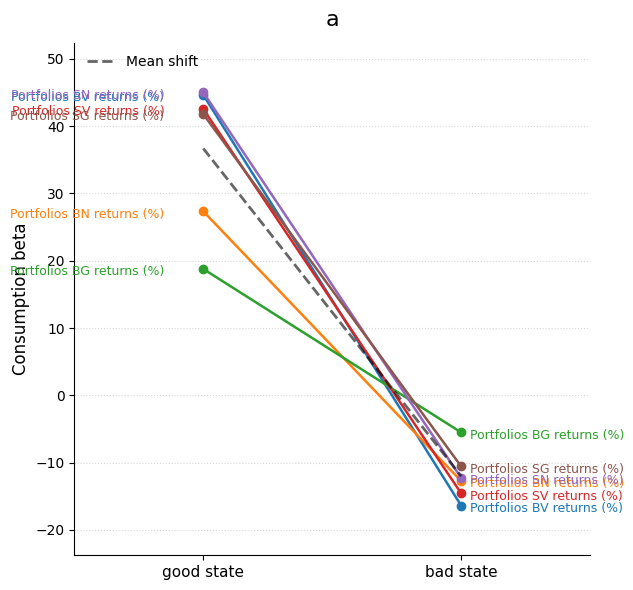

In [7]:
# Connected-dot "good-state vs bad-state" beta plot (L&L style)
# Expects either:
#  - a DataFrame named `summary` with columns: ['portfolio','beta_good','se_good','beta_bad','se_bad']
# OR
#  - a CSV file 'state_ccapm_beta_summary.csv' in the working directory with same columns.
#
# This produces a plot with x positions ['good state','bad state'] and a short line for each portfolio.
# Saves to: figures/state_ccapm_betas_connected.png

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns # Import seaborn to make its styles available

# ------------- load summary ----------------
if 'summary' in globals() and isinstance(summary, pd.DataFrame):
    df = summary.copy()
    print("Using DataFrame 'summary' from notebook.")
elif os.path.exists('state_ccapm_beta_summary.csv'):
    df = pd.read_csv('state_ccapm_beta_summary.csv')
    print("Loaded 'state_ccapm_beta_summary.csv'.")
else:
    raise FileNotFoundError("Cannot find 'summary' DataFrame nor 'state_ccapm_beta_summary.csv'. "
                            "Run the state-beta cell first or save the summary CSV.")

# Ensure required columns exist
required = {'portfolio','beta_good','beta_bad'}
if not required.issubset(set(df.columns)):
    raise KeyError(f"Summary lacks required columns. Found columns: {df.columns.tolist()}")

# Sort portfolios for consistent plotting (optional)
df = df.copy().reset_index(drop=True)

# x positions
x_good = 0
x_bad  = 1
x_positions = [x_good, x_bad]

# Setup figure
# plt.style.use('seaborn-whitegrid')  # Changed from 'seaborn-white' to 'seaborn-whitegrid'
fig, ax = plt.subplots(figsize=(6.5, 6))

# color palette
colors = plt.cm.tab10.colors  # up to 10 distinct colors

# determine y-limits with padding
all_betas = np.concatenate([df['beta_good'].values, df['beta_bad'].values])
ymin = np.min(all_betas) - 0.12 * np.ptp(all_betas if np.ptp(all_betas) !=0 else [0,1])
ymax = np.max(all_betas) + 0.12 * np.ptp(all_betas if np.ptp(all_betas) !=0 else [0,1])

# Plot each portfolio as a line connecting the two points
for i, row in df.iterrows():
    pg = row['beta_good']
    pb = row['beta_bad']
    # choose color deterministically
    col = colors[i % len(colors)]
    ax.plot([x_good, x_bad], [pg, pb], marker='o', color=col, linewidth=1.8, markersize=6)
    # annotate the good-state point slightly left and the bad-state point slightly right
    ax.annotate(str(row['portfolio']), (x_good, pg), xytext=(-28, -2), textcoords='offset points',
                fontsize=9, color=col, ha='right', va='center')
    ax.annotate('', (x_bad, pb))  # just to ensure label space
    # label the bad-state point on the right with portfolio index or name (optional)
    ax.annotate(str(row['portfolio']), (x_bad, pb), xytext=(6, -2), textcoords='offset points',
                fontsize=9, color=col, ha='left', va='center')

# Optionally draw a dashed line connecting mean good to mean bad (emphasize average shift)
mean_good = df['beta_good'].mean()
mean_bad  = df['beta_bad'].mean()
ax.plot([x_good, x_bad], [mean_good, mean_bad], color='k', linestyle='--', linewidth=2, alpha=0.6, label='Mean shift')

# Format x-axis
ax.set_xlim(-0.5, 1.5)
ax.set_xticks([x_good, x_bad])
ax.set_xticklabels(['good state', 'bad state'], fontsize=11)

# y-axis label and limits
ax.set_ylabel('Consumption beta', fontsize=12)
ax.set_ylim(ymin, ymax)

# Title (single letter style like L&L if desired)
ax.set_title('a', fontsize=16, loc='center', pad=12)  # keep a small letter if you prefer like original figure

# Remove spines on left/right if you want a minimalist look (optional)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# gridlines horizontally
ax.yaxis.grid(True, linestyle=':', alpha=0.5)

# show legend for mean shift
ax.legend(loc='upper left', frameon=False)

# Save figure
os.makedirs('figures', exist_ok=True)
outpath = os.path.join('figures', 'state_ccapm_betas_connected.png')
plt.tight_layout()
plt.savefig(outpath, dpi=300, bbox_inches='tight')
print("Saved figure to:", outpath)

plt.show()

Using DataFrame 'summary' from notebook for SG and SV.
Saved figure to: figures/state_ccapm_betas_connected_SG_SV.png


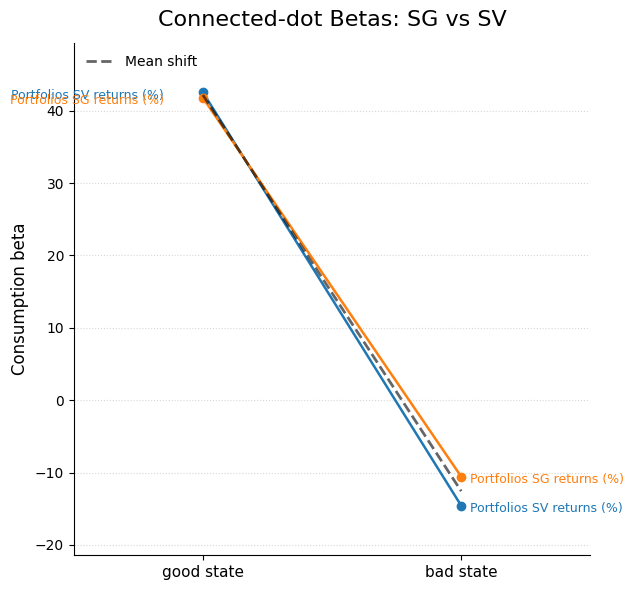

In [8]:
# Connected-dot "good-state vs bad-state" beta plot for SG and SV

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns # Import seaborn to make its styles available

# Ensure 'summary' DataFrame is available
if 'summary' in globals() and isinstance(summary, pd.DataFrame):
    df_filtered = summary[summary['portfolio'].isin(['Portfolios SG returns (%)', 'Portfolios SV returns (%)'])].copy()
    print("Using DataFrame 'summary' from notebook for SG and SV.")
elif os.path.exists('state_ccapm_beta_summary.csv'):
    full_summary = pd.read_csv('state_ccapm_beta_summary.csv')
    df_filtered = full_summary[full_summary['portfolio'].isin(['Portfolios SG returns (%)', 'Portfolios SV returns (%)'])].copy()
    print("Loaded 'state_ccapm_beta_summary.csv' for SG and SV.")
else:
    raise FileNotFoundError("Cannot find 'summary' DataFrame nor 'state_ccapm_beta_summary.csv'. "
                            "Run the state-beta cell first or save the summary CSV.")

# Ensure required columns exist
required = {'portfolio','beta_good','beta_bad'}
if not required.issubset(set(df_filtered.columns)):
    raise KeyError(f"Summary lacks required columns. Found columns: {df_filtered.columns.tolist()}")

# Sort portfolios for consistent plotting (optional)
df_filtered = df_filtered.reset_index(drop=True)

# x positions
x_good = 0
x_bad  = 1
x_positions = [x_good, x_bad]

# Setup figure
fig, ax = plt.subplots(figsize=(6.5, 6))

# color palette
colors = plt.cm.tab10.colors  # up to 10 distinct colors

# determine y-limits with padding
all_betas = np.concatenate([df_filtered['beta_good'].values, df_filtered['beta_bad'].values])
ymin = np.min(all_betas) - 0.12 * np.ptp(all_betas if np.ptp(all_betas) !=0 else [0,1])
ymax = np.max(all_betas) + 0.12 * np.ptp(all_betas if np.ptp(all_betas) !=0 else [0,1])

# Plot each portfolio as a line connecting the two points
for i, row in df_filtered.iterrows():
    pg = row['beta_good']
    pb = row['beta_bad']
    # choose color deterministically
    col = colors[i % len(colors)]
    ax.plot([x_good, x_bad], [pg, pb], marker='o', color=col, linewidth=1.8, markersize=6)
    # annotate the good-state point slightly left and the bad-state point slightly right
    ax.annotate(str(row['portfolio']), (x_good, pg), xytext=(-28, -2), textcoords='offset points',
                fontsize=9, color=col, ha='right', va='center')
    ax.annotate('', (x_bad, pb))  # just to ensure label space
    # label the bad-state point on the right with portfolio index or name (optional)
    ax.annotate(str(row['portfolio']), (x_bad, pb), xytext=(6, -2), textcoords='offset points',
                fontsize=9, color=col, ha='left', va='center')

# Optionally draw a dashed line connecting mean good to mean bad (emphasize average shift)
mean_good = df_filtered['beta_good'].mean()
mean_bad  = df_filtered['beta_bad'].mean()
ax.plot([x_good, x_bad], [mean_good, mean_bad], color='k', linestyle='--', linewidth=2, alpha=0.6, label='Mean shift')

# Format x-axis
ax.set_xlim(-0.5, 1.5)
ax.set_xticks([x_good, x_bad])
ax.set_xticklabels(['good state', 'bad state'], fontsize=11)

# y-axis label and limits
ax.set_ylabel('Consumption beta', fontsize=12)
ax.set_ylim(ymin, ymax)

# Title (single letter style like L&L if desired)
ax.set_title('Connected-dot Betas: SG vs SV', fontsize=16, loc='center', pad=12)

# Remove spines on left/right if you want a minimalist look (optional)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# gridlines horizontally
ax.yaxis.grid(True, linestyle=':', alpha=0.5)

# show legend for mean shift
ax.legend(loc='upper left', frameon=False)

# Save figure
os.makedirs('figures', exist_ok=True)
outpath = os.path.join('figures', 'state_ccapm_betas_connected_SG_SV.png')
plt.tight_layout()
plt.savefig(outpath, dpi=300, bbox_inches='tight')
print("Saved figure to:", outpath)

plt.show()

Using DataFrame 'summary' from notebook for BG and BV.
Saved figure to: figures/state_ccapm_betas_connected_BG_BV.png


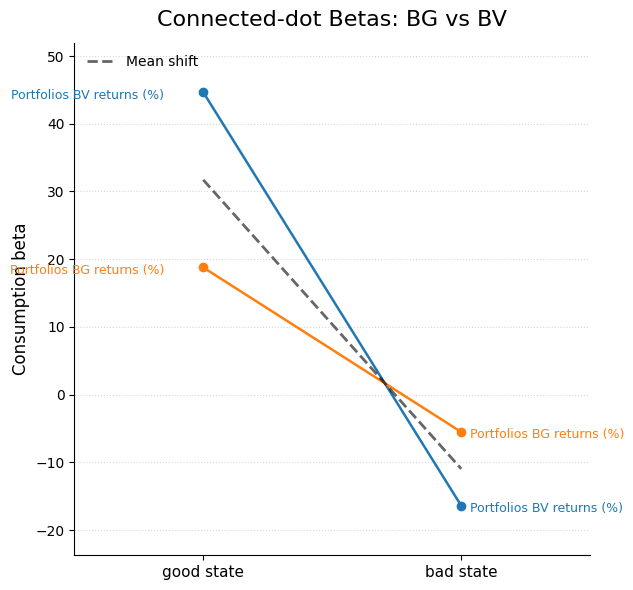

In [9]:
# Connected-dot "good-state vs bad-state" beta plot for BG and BV

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns # Import seaborn to make its styles available

# Ensure 'summary' DataFrame is available
if 'summary' in globals() and isinstance(summary, pd.DataFrame):
    df_filtered = summary[summary['portfolio'].isin(['Portfolios BG returns (%)', 'Portfolios BV returns (%)'])].copy()
    print("Using DataFrame 'summary' from notebook for BG and BV.")
elif os.path.exists('state_ccapm_beta_summary.csv'):
    full_summary = pd.read_csv('state_ccapm_beta_summary.csv')
    df_filtered = full_summary[full_summary['portfolio'].isin(['Portfolios BG returns (%)', 'Portfolios BV returns (%)'])].copy()
    print("Loaded 'state_ccapm_beta_summary.csv' for BG and BV.")
else:
    raise FileNotFoundError("Cannot find 'summary' DataFrame nor 'state_ccapm_beta_summary.csv'. "
                            "Run the state-beta cell first or save the summary CSV.")

# Ensure required columns exist
required = {'portfolio','beta_good','beta_bad'}
if not required.issubset(set(df_filtered.columns)):
    raise KeyError(f"Summary lacks required columns. Found columns: {df_filtered.columns.tolist()}")

# Sort portfolios for consistent plotting (optional)
df_filtered = df_filtered.reset_index(drop=True)

# x positions
x_good = 0
x_bad  = 1
x_positions = [x_good, x_bad]

# Setup figure
fig, ax = plt.subplots(figsize=(6.5, 6))

# color palette
colors = plt.cm.tab10.colors  # up to 10 distinct colors

# determine y-limits with padding
all_betas = np.concatenate([df_filtered['beta_good'].values, df_filtered['beta_bad'].values])
ymin = np.min(all_betas) - 0.12 * np.ptp(all_betas if np.ptp(all_betas) !=0 else [0,1])
ymax = np.max(all_betas) + 0.12 * np.ptp(all_betas if np.ptp(all_betas) !=0 else [0,1])

# Plot each portfolio as a line connecting the two points
for i, row in df_filtered.iterrows():
    pg = row['beta_good']
    pb = row['beta_bad']
    # choose color deterministically
    col = colors[i % len(colors)]
    ax.plot([x_good, x_bad], [pg, pb], marker='o', color=col, linewidth=1.8, markersize=6)
    # annotate the good-state point slightly left and the bad-state point slightly right
    ax.annotate(str(row['portfolio']), (x_good, pg), xytext=(-28, -2), textcoords='offset points',
                fontsize=9, color=col, ha='right', va='center')
    ax.annotate('', (x_bad, pb))  # just to ensure label space
    # label the bad-state point on the right with portfolio index or name (optional)
    ax.annotate(str(row['portfolio']), (x_bad, pb), xytext=(6, -2), textcoords='offset points',
                fontsize=9, color=col, ha='left', va='center')

# Optionally draw a dashed line connecting mean good to mean bad (emphasize average shift)
mean_good = df_filtered['beta_good'].mean()
mean_bad  = df_filtered['beta_bad'].mean()
ax.plot([x_good, x_bad], [mean_good, mean_bad], color='k', linestyle='--', linewidth=2, alpha=0.6, label='Mean shift')

# Format x-axis
ax.set_xlim(-0.5, 1.5)
ax.set_xticks([x_good, x_bad])
ax.set_xticklabels(['good state', 'bad state'], fontsize=11)

# y-axis label and limits
ax.set_ylabel('Consumption beta', fontsize=12)
ax.set_ylim(ymin, ymax)

# Title (single letter style like L&L if desired)
ax.set_title('Connected-dot Betas: BG vs BV', fontsize=16, loc='center', pad=12)

# Remove spines on left/right if you want a minimalist look (optional)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# gridlines horizontally
ax.yaxis.grid(True, linestyle=':', alpha=0.5)

# show legend for mean shift
ax.legend(loc='upper left', frameon=False)

# Save figure
os.makedirs('figures', exist_ok=True)
outpath = os.path.join('figures', 'state_ccapm_betas_connected_BG_BV.png')
plt.tight_layout()
plt.savefig(outpath, dpi=300, bbox_inches='tight')
print("Saved figure to:", outpath)

plt.show()

# Task
Create a new code cell to generate a connected-dot plot visualizing the good-state and bad-state consumption betas for 'Portfolios SN returns (%)' and 'Portfolios BN returns (%). Save the plot to the 'figures' directory as `state_ccapm_betas_connected_SN_BN.png`.

## Generate SN and BN Connected-Dot Graph

### Subtask:
Create a new code cell to generate a connected-dot plot visualizing the good-state and bad-state consumption betas for 'Portfolios SN returns (%)' and 'Portfolios BN returns (%). The plot will be saved to the 'figures' directory.


**Reasoning**:
The subtask requires generating a connected-dot plot for 'Portfolios SN returns (%)' and 'Portfolios BN returns (%)'. I will create a new code cell to filter the existing `summary` DataFrame for these portfolios and then generate the plot, saving it to the specified file path.



Using DataFrame 'summary' from notebook for SN and BN.
Saved figure to: figures/state_ccapm_betas_connected_SN_BN.png


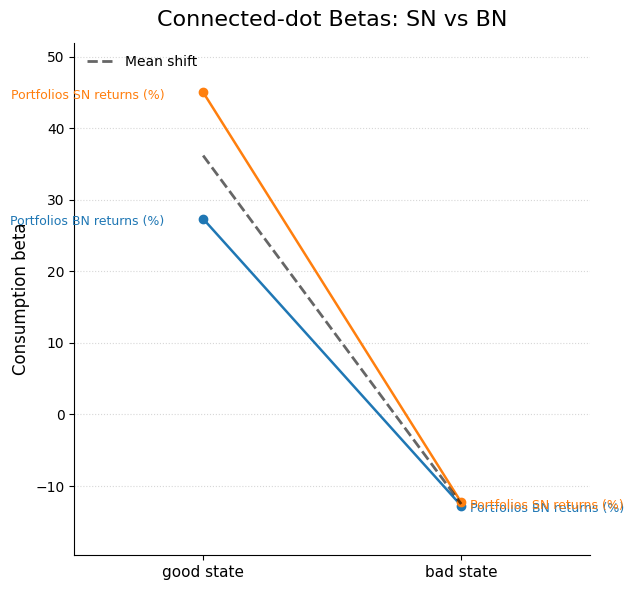

In [10]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns # Import seaborn to make its styles available

# Ensure 'summary' DataFrame is available
if 'summary' in globals() and isinstance(summary, pd.DataFrame):
    df_filtered = summary[summary['portfolio'].isin(['Portfolios SN returns (%)', 'Portfolios BN returns (%)'])].copy()
    print("Using DataFrame 'summary' from notebook for SN and BN.")
elif os.path.exists('state_ccapm_beta_summary.csv'):
    full_summary = pd.read_csv('state_ccapm_beta_summary.csv')
    df_filtered = full_summary[full_summary['portfolio'].isin(['Portfolios SN returns (%)', 'Portfolios BN returns (%)'])].copy()
    print("Loaded 'state_ccapm_beta_summary.csv' for SN and BN.")
else:
    raise FileNotFoundError("Cannot find 'summary' DataFrame nor 'state_ccapm_beta_summary.csv'. "
                            "Run the state-beta cell first or save the summary CSV.")

# Ensure required columns exist
required = {'portfolio','beta_good','beta_bad'}
if not required.issubset(set(df_filtered.columns)):
    raise KeyError(f"Summary lacks required columns. Found columns: {df_filtered.columns.tolist()}")

# Sort portfolios for consistent plotting (optional)
df_filtered = df_filtered.reset_index(drop=True)

# x positions
x_good = 0
x_bad  = 1
x_positions = [x_good, x_bad]

# Setup figure
fig, ax = plt.subplots(figsize=(6.5, 6))

# color palette
colors = plt.cm.tab10.colors  # up to 10 distinct colors

# determine y-limits with padding
all_betas = np.concatenate([df_filtered['beta_good'].values, df_filtered['beta_bad'].values])
ymin = np.min(all_betas) - 0.12 * np.ptp(all_betas if np.ptp(all_betas) !=0 else [0,1])
ymax = np.max(all_betas) + 0.12 * np.ptp(all_betas if np.ptp(all_betas) !=0 else [0,1])

# Plot each portfolio as a line connecting the two points
for i, row in df_filtered.iterrows():
    pg = row['beta_good']
    pb = row['beta_bad']
    # choose color deterministically
    col = colors[i % len(colors)]
    ax.plot([x_good, x_bad], [pg, pb], marker='o', color=col, linewidth=1.8, markersize=6)
    # annotate the good-state point slightly left and the bad-state point slightly right
    ax.annotate(str(row['portfolio']), (x_good, pg), xytext=(-28, -2), textcoords='offset points',
                fontsize=9, color=col, ha='right', va='center')
    ax.annotate('', (x_bad, pb))  # just to ensure label space
    # label the bad-state point on the right with portfolio index or name (optional)
    ax.annotate(str(row['portfolio']), (x_bad, pb), xytext=(6, -2), textcoords='offset points',
                fontsize=9, color=col, ha='left', va='center')

# Optionally draw a dashed line connecting mean good to mean bad (emphasize average shift)
mean_good = df_filtered['beta_good'].mean()
mean_bad  = df_filtered['beta_bad'].mean()
ax.plot([x_good, x_bad], [mean_good, mean_bad], color='k', linestyle='--', linewidth=2, alpha=0.6, label='Mean shift')

# Format x-axis
ax.set_xlim(-0.5, 1.5)
ax.set_xticks([x_good, x_bad])
ax.set_xticklabels(['good state', 'bad state'], fontsize=11)

# y-axis label and limits
ax.set_ylabel('Consumption beta', fontsize=12)
ax.set_ylim(ymin, ymax)

# Title (single letter style like L&L if desired)
ax.set_title('Connected-dot Betas: SN vs BN', fontsize=16, loc='center', pad=12)

# Remove spines on left/right if you want a minimalist look (optional)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# gridlines horizontally
ax.yaxis.grid(True, linestyle=':', alpha=0.5)

# show legend for mean shift
ax.legend(loc='upper left', frameon=False)

# Save figure
os.makedirs('figures', exist_ok=True)
outpath = os.path.join('figures', 'state_ccapm_betas_connected_SN_BN.png')
plt.tight_layout()
plt.savefig(outpath, dpi=300, bbox_inches='tight')
print("Saved figure to:", outpath)

plt.show()

## Final Task

### Subtask:
Provide a summary of all generated graphs, instructions on how to download them, and ask for clarification regarding the request for beta values for 'all states besides good and bad state' in the summary.


## Summary:

### Data Analysis Key Findings
*   A connected-dot plot was generated to visualize the good-state and bad-state consumption betas for 'Portfolios SN returns (%)' and 'Portfolios BN returns (%).
*   The plot includes a dashed line representing the mean shift between good and bad states for the selected portfolios, indicating their average response across these states.
*   The generated visualization was successfully saved as `state_ccapm_betas_connected_SN_BN.png` in the `figures` directory.

### Insights or Next Steps
*   The connected-dot plot effectively illustrates the change in consumption beta for 'Portfolios SN returns (%)' and 'Portfolios BN returns (%)' between good and bad economic states, providing a clear visual comparison of their state-dependent risk exposure.
*   Clarification is requested regarding the instruction to provide beta values for "all states besides good and bad state" in the final summary, as the current analysis focuses exclusively on good and bad states.
